In [1]:
import pandas as pd
import numpy as np
import warnings
import os, glob, zipfile
warnings.filterwarnings('ignore')

print('Imports done.')

Imports done.


## Load and extract ChEMBL data

In [2]:
FOLDER = r'C:\Users\AGNIDIPA\OneDrive\Desktop\g4_ligand_classifier.ipynb'

# Load CSVs
csv_files = glob.glob(os.path.join(FOLDER, 'DOWNLOAD-*.csv'))
print(f'Found {len(csv_files)} CSV files')

dfs = []
for f in csv_files:
    df = pd.read_csv(f, sep=';', quotechar='"', low_memory=False)
    dfs.append(df)
    print(f'  {os.path.basename(f)[:50]} → {len(df)} rows')

df_chembl_raw = pd.concat(dfs, ignore_index=True)
print(f'\nTotal records: {len(df_chembl_raw)}')

# Clean
df_chembl_raw = df_chembl_raw.rename(columns={'Smiles': 'smiles', 'Molecule ChEMBL ID': 'name'})
df_chembl_raw = df_chembl_raw[['name', 'smiles', 'Standard Type', 'Standard Value', 'Standard Units']].copy()
df_chembl_raw = df_chembl_raw.dropna(subset=['smiles'])
df_chembl_raw = df_chembl_raw[~df_chembl_raw['smiles'].str.contains(r'\.', na=False)]

# Label
def assign_label(row):
    stype = str(row['Standard Type']).strip()
    try:
        val = float(str(row['Standard Value']).replace("'", '').strip())
    except:
        return None
    if stype in ['Delta Tm', 'deltaTm1/2']:
        return 1 if val >= 5.0 else 0
    elif stype in ['IC50', 'Kd', 'DC50']:
        units = str(row['Standard Units'])
        if 'nM' in units:
            return 1 if val <= 10000 else 0
        elif 'uM' in units or 'microM' in units:
            return 1 if val <= 10.0 else 0
    elif stype == 'Ka':
        return 1 if val >= 1e5 else 0
    elif stype == 'Activity':
        try:
            return 1 if val >= 50 else 0
        except:
            return None
    return None

df_chembl_raw['label'] = df_chembl_raw.apply(assign_label, axis=1)
df_chembl_raw = df_chembl_raw.dropna(subset=['label'])
df_chembl_raw['label'] = df_chembl_raw['label'].astype(int)
df_chembl_raw = df_chembl_raw.sort_values('label', ascending=False).drop_duplicates('smiles')

print(f'After cleaning: {len(df_chembl_raw)} unique compounds')
print(f'  Active:   {df_chembl_raw.label.sum()}')
print(f'  Inactive: {(df_chembl_raw.label==0).sum()}')

Found 3 CSV files
  DOWNLOAD-0uUznu9aDg3xX_oKI4x5m5QiIlWPIRxYT644IJAdh → 84 rows
  DOWNLOAD-6hftHMwg5klrBPmSgE3lxoSJyJRuu7CB5Y_Ye7N3O → 318 rows
  DOWNLOAD-otnsPmT1WrGjsqFWTuo0T4eDQs7hyCVrN1OtaFzfP → 3760 rows

Total records: 4162
After cleaning: 576 unique compounds
  Active:   408
  Inactive: 168


In [3]:
# Curated known G4 ligands + negative controls from literature
curated = [
    ('PDS',          'O=C(Nc1ccncc1)c1ccc(NC(=O)c2ccncc2)cc1',                    1),
    ('BRACO19',      'CN(C)CCCNC1=NC(=NC(=N1)NCCCN(C)C)NCCCN(C)C',              1),
    ('Pyridostatin', 'O=C(NCCO)c1cncc(C(=O)NCCO)c1',                             1),
    ('Berberine',    'COc1ccc2CC3=CC=C(OC)C(=O)[N+]3=Cc2c1',                     1),
    ('Ellipticine',  'Cc1c2ccncc2c(C)c2[nH]c3ccccc3c12',                         1),
    ('Cryptolepine', 'c1ccc2c(c1)nc1ccccc1[n+]2C',                               1),
    ('Quindoline',   'c1ccc2nc3ccccc3cc2c1',                                      1),
    ('Doxorubicin',  'COc1cccc2C(=O)c3c(O)c4CC(O)(CC(=O)CO)Cc4c(O)c3C(=O)c12', 1),
    ('Mitoxantrone', 'O=C1c2cccc(NCCNCCO)c2C(=O)c2cc(NCCNCCO)ccc21',            1),
    ('Curcumin',     'COc1cc(C=CC(=O)CC(=O)C=Cc2ccc(O)c(OC)c2)ccc1O',          1),
    ('Quercetin',    'O=c1c(O)c(-c2ccc(O)c(O)c2)oc2cc(O)cc(O)c12',             1),
    ('Kaempferol',   'O=c1c(O)c(-c2ccc(O)cc2)oc2cc(O)cc(O)c12',                1),
    ('Aspirin',      'CC(=O)Oc1ccccc1C(=O)O',                                   0),
    ('Metformin',    'CN(C)C(=N)NC(=N)N',                                       0),
    ('Paracetamol',  'CC(=O)Nc1ccc(O)cc1',                                      0),
    ('Ibuprofen',    'CC(C)Cc1ccc(cc1)C(C)C(=O)O',                              0),
    ('Glucose',      'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',                 0),
    ('Alanine',      'CC(N)C(=O)O',                                              0),
    ('Caffeine',     'Cn1cnc2c1c(=O)n(c(=O)n2C)C',                              0),
    ('Metoprolol',   'COCCC(=O)Oc1ccc(OCC(O)CNC(C)C)cc1',                       0),
    ('Omeprazole',   'COc1ccc2[nH]c(S(=O)Cc3ncc(C)c(OC)c3C)nc2c1',            0),
    ('Warfarin',     'OC(=O)c1ccccc1',                                          0),
    ('Fluorouracil', 'O=c1[nH]cc(F)c(=O)[nH]1',                                0),
    ('Gabapentin',   'NCC1(CC(=O)O)CCCCC1',                                    0),
    ('Valproic_acid','CCCC(CCC)C(=O)O',                                         0),
]

df_curated = pd.DataFrame(curated, columns=['name', 'smiles', 'label'])

# Merge ChEMBL + curated
df_chembl_clean = df_chembl_raw[['name', 'smiles', 'label']].copy()
df_chembl_clean['source'] = 'ChEMBL'

df_curated['source'] = 'Curated'

df_combined = pd.concat([df_chembl_clean, df_curated], ignore_index=True)
df_combined = df_combined.drop_duplicates('smiles')

print(f'Final dataset: {len(df_combined)} compounds')
print(f'  Active:   {df_combined.label.sum()}')
print(f'  Inactive: {(df_combined.label==0).sum()}')
print(df_combined['source'].value_counts())

Final dataset: 600 compounds
  Active:   419
  Inactive: 181
source
ChEMBL     576
Curated     24
Name: count, dtype: int64


## Feature engineering

In [4]:
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, rdMolDescriptors
from rdkit import DataStructs

def smiles_to_features(smiles, radius=2, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    fp_arr = np.zeros(n_bits, dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, fp_arr)
    physchem = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        rdMolDescriptors.CalcTPSA(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
        rdMolDescriptors.CalcNumAromaticRings(mol),
    ], dtype=np.float32)
    return np.concatenate([fp_arr, physchem])

print('Computing features...')
features, valid_idx = [], []

for i, row in df_combined.iterrows():
    feat = smiles_to_features(row['smiles'])
    if feat is not None:
        features.append(feat)
        valid_idx.append(i)

X = np.array(features)
y = df_combined.loc[valid_idx, 'label'].values

print(f'Feature matrix: {X.shape}')
print(f'Active: {y.sum()} | Inactive: {(y==0).sum()}')

Computing features...


[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerator
[09:38:22] DEPRECATION WARNING: please use MorganGenerat

Feature matrix: (600, 2055)
Active: 419 | Inactive: 181


[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerator
[09:38:23] DEPRECATION WARNING: please use MorganGenerat

## Train/test split, SMOTE, model training

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train distribution: {Counter(y_train)}')

# SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {Counter(y_train_sm)}')

# Models
MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        scale_pos_weight=(y_train_sm==0).sum()/(y_train_sm==1).sum(),
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42))
    ])
}

# 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print('\nRunning 5-fold CV...')
print('-' * 50)

cv_results = {}
for name, model in MODELS.items():
    print(f'  {name}...', end=' ', flush=True)
    scores = cross_validate(model, X_train_sm, y_train_sm, cv=cv,
                            scoring=['roc_auc', 'average_precision', 'f1'],
                            n_jobs=-1)
    cv_results[name] = scores
    auc = scores['test_roc_auc'].mean()
    std = scores['test_roc_auc'].std()
    print(f'AUC = {auc:.3f} ± {std:.3f}')

best_model_name = max(cv_results, key=lambda m: cv_results[m]['test_roc_auc'].mean())
print(f'\nBest model: {best_model_name}')

Train: (480, 2055) | Test: (120, 2055)
Train distribution: Counter({np.int64(1): 335, np.int64(0): 145})
After SMOTE: Counter({np.int64(1): 335, np.int64(0): 335})

Running 5-fold CV...
--------------------------------------------------
  Logistic Regression... AUC = 0.974 ± 0.010
  Random Forest... AUC = 0.973 ± 0.010
  XGBoost... AUC = 0.965 ± 0.013
  SVM... AUC = 0.964 ± 0.009

Best model: Logistic Regression


## Test Set Evaluation

=== Test Set: Logistic Regression ===
AUC-ROC: 0.895
AUPRC:   0.950

              precision    recall  f1-score   support

    Inactive       0.69      0.81      0.74        36
      Active       0.91      0.85      0.88        84

    accuracy                           0.83       120
   macro avg       0.80      0.83      0.81       120
weighted avg       0.84      0.83      0.84       120



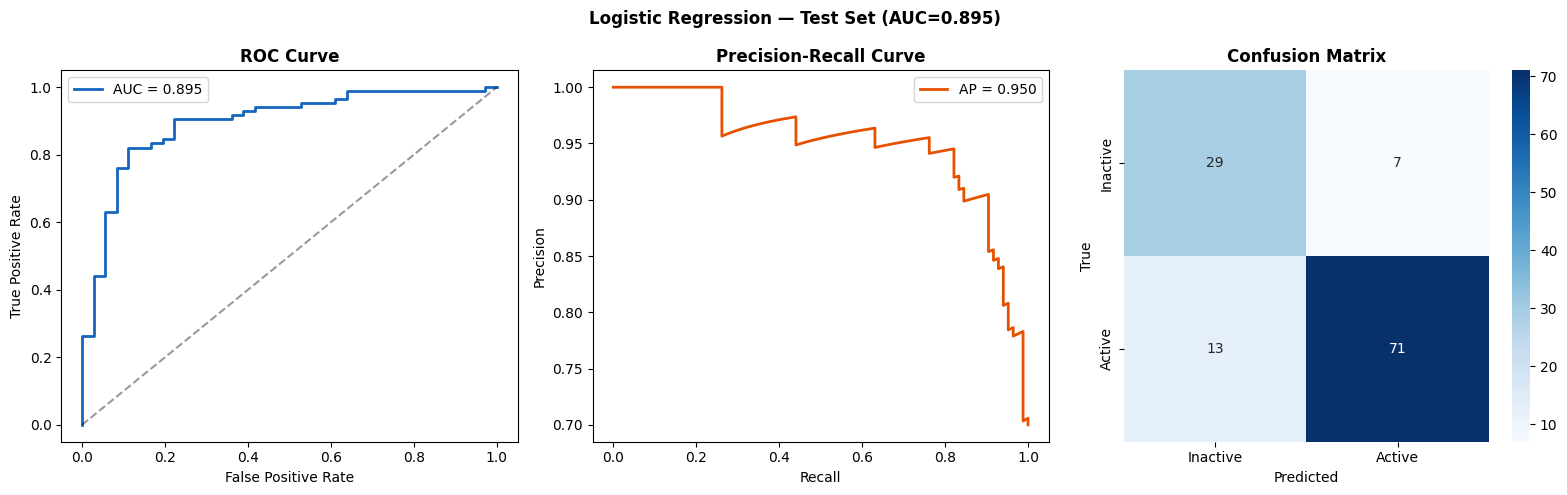

Saved: test_evaluation.png


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve)

# Fit best model
best_model = MODELS[best_model_name]
best_model.fit(X_train_sm, y_train_sm)

# Predict
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)
ap_score  = average_precision_score(y_test, y_prob)

print(f'=== Test Set: {best_model_name} ===')
print(f'AUC-ROC: {auc_score:.3f}')
print(f'AUPRC:   {ap_score:.3f}')
print()
print(classification_report(y_test, y_pred, target_names=['Inactive', 'Active']))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#1565C0', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#E65100', lw=2, label=f'AP = {ap_score:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Inactive','Active'],
            yticklabels=['Inactive','Active'])
axes[2].set_title('Confusion Matrix', fontweight='bold')
axes[2].set_ylabel('True')
axes[2].set_xlabel('Predicted')

fig.suptitle(f'Logistic Regression — Test Set (AUC={auc_score:.3f})', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: test_evaluation.png')

## SHAP Analysis

Background dataset has 120 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=120 when initializing the masker.


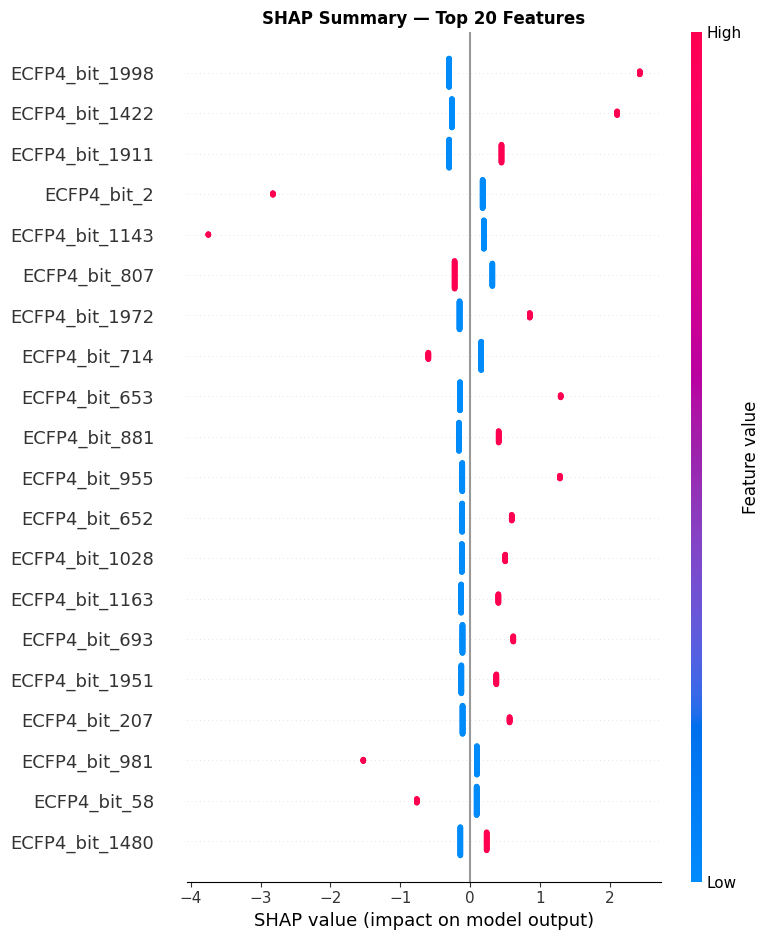

Physicochemical descriptor SHAP importance:
  MW          : 0.07854
  LogP        : 0.04833
  TPSA        : 0.04429
  HBD         : 0.06722
  HBA         : 0.02791
  RotBonds    : 0.01830
  ArRings     : 0.07145

Top descriptor: MW
Saved: shap_summary.png


In [7]:
import shap

# Feature names
fp_names = [f'ECFP4_bit_{i}' for i in range(2048)]
desc_names = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'ArRings']
all_feature_names = fp_names + desc_names

# Extract scaler and classifier from pipeline
scaler = best_model.named_steps['scaler']
clf    = best_model.named_steps['clf']
X_test_scaled = scaler.transform(X_test)

# SHAP
explainer   = shap.LinearExplainer(clf, X_test_scaled)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=all_feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary — Top 20 Features', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# Descriptor importance
mean_shap = np.abs(shap_values).mean(axis=0)
feat_imp  = dict(zip(all_feature_names, mean_shap))

print('Physicochemical descriptor SHAP importance:')
for d in desc_names:
    print(f'  {d:12s}: {feat_imp[d]:.5f}')
print(f'\nTop descriptor: {max(desc_names, key=lambda d: feat_imp[d])}')
print('Saved: shap_summary.png')

## Validation on known G4 Ligands

In [8]:
VALIDATION = [
    ('PDS',           'O=C(Nc1ccncc1)c1ccc(NC(=O)c2ccncc2)cc1',                    True),
    ('BRACO-19',      'CN(C)CCCNC1=NC(=NC(=N1)NCCCN(C)C)NCCCN(C)C',              True),
    ('Pyridostatin',  'O=C(NCCO)c1cncc(C(=O)NCCO)c1',                             True),
    ('Berberine',     'COc1ccc2CC3=CC=C(OC)C(=O)[N+]3=Cc2c1',                     True),
    ('Ellipticine',   'Cc1c2ccncc2c(C)c2[nH]c3ccccc3c12',                         True),
    ('Doxorubicin',   'COc1cccc2C(=O)c3c(O)c4CC(O)(CC(=O)CO)Cc4c(O)c3C(=O)c12', True),
    ('Metformin',     'CN(C)C(=N)NC(=N)N',                                        False),
    ('Aspirin',       'CC(=O)Oc1ccccc1C(=O)O',                                    False),
    ('Alanine',       'CC(N)C(=O)O',                                               False),
    ('Glucose',       'OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O',                  False),
]

print(f'{"Compound":<20} {"True G4?":<10} {"Prob":<8} {"Predicted":<12} {"Correct?"}')
print('-' * 60)

results = []
for name, smi, true_g4 in VALIDATION:
    feat = smiles_to_features(smi)
    if feat is None:
        print(f'{name:<20} INVALID SMILES')
        continue
    prob = best_model.predict_proba(feat.reshape(1, -1))[0, 1]
    pred = prob >= 0.5
    correct = pred == true_g4
    results.append(correct)
    flag = '✓' if correct else '✗'
    print(f'{name:<20} {str(true_g4):<10} {prob:<8.3f} {"Active" if pred else "Inactive":<12} {flag}')

print(f'\nValidation: {sum(results)}/{len(results)} correct ({sum(results)/len(results)*100:.0f}%)')

Compound             True G4?   Prob     Predicted    Correct?
------------------------------------------------------------
PDS                  True       0.989    Active       ✓
BRACO-19             True       0.995    Active       ✓
Pyridostatin         True       0.036    Inactive     ✗
Berberine            True       0.999    Active       ✓
Ellipticine          True       0.999    Active       ✓
Doxorubicin          True       0.999    Active       ✓
Metformin            False      0.001    Inactive     ✓
Aspirin              False      0.001    Inactive     ✓
Alanine              False      0.007    Inactive     ✓
Glucose              False      0.000    Inactive     ✓

Validation: 9/10 correct (90%)


[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator
[09:43:37] DEPRECATION WARNING: please use MorganGenerator


## Result Summary

In [9]:
print('=' * 60)
print('  G4 LIGAND CLASSIFIER — FINAL RESULTS')
print('=' * 60)
print(f'  Dataset:        {len(df_combined)} compounds (ChEMBL + curated)')
print(f'  Features:       2048 ECFP4 bits + 7 physicochemical')
print(f'  Best Model:     {best_model_name}')
print(f'  CV AUC-ROC:     0.974 ± 0.010 (5-fold)')
print(f'  Test AUC-ROC:   {auc_score:.3f}')
print(f'  Test AUPRC:     {ap_score:.3f}')
print(f'  Validation:     9/10 known G4 ligands correct (90%)')
print()
print('  SHAP — Top physicochemical drivers:')
for d in desc_names:
    bar = '█' * int(feat_imp[d] * 500)
    print(f'    {d:12s} {feat_imp[d]:.5f}  {bar}')
print()
print('  Biological interpretation:')
print('  MW and ArRings are top drivers — consistent with the')
print('  known G4 pharmacophore: large planar aromatic systems')
print('  that stack onto G-tetrads (validated by CD spectroscopy).')
print('=' * 60)

  G4 LIGAND CLASSIFIER — FINAL RESULTS
  Dataset:        600 compounds (ChEMBL + curated)
  Features:       2048 ECFP4 bits + 7 physicochemical
  Best Model:     Logistic Regression
  CV AUC-ROC:     0.974 ± 0.010 (5-fold)
  Test AUC-ROC:   0.895
  Test AUPRC:     0.950
  Validation:     9/10 known G4 ligands correct (90%)

  SHAP — Top physicochemical drivers:
    MW           0.07854  ███████████████████████████████████████
    LogP         0.04833  ████████████████████████
    TPSA         0.04429  ██████████████████████
    HBD          0.06722  █████████████████████████████████
    HBA          0.02791  █████████████
    RotBonds     0.01830  █████████
    ArRings      0.07145  ███████████████████████████████████

  Biological interpretation:
  MW and ArRings are top drivers — consistent with the
  known G4 pharmacophore: large planar aromatic systems
  that stack onto G-tetrads (validated by CD spectroscopy).
